In [ ]:
import tensorflow as tf
import numpy as np
#import matplotlib.pyplot as plt
import pandas as pd
import pyfaidx
from collections import Counter, defaultdict, OrderedDict
#from modisco.visualization import viz_sequence
import logomaker
from copy import deepcopy
from tqdm import tqdm
from tqdm import tnrange
import deepdish
import pyBigWig
import tqdm
import sys
import pyfaidx
import pysam
sys.path.append("../../../chrombpnet/")
from training.utils.losses import multinomial_nll
from training.utils.one_hot import dna_to_one_hot
from evaluation.interpret.shap_utils import *
#from utils.data_utils import load_test_data, get_seq
#from training.utils.data_utils import get_seq, get_seq_cts
import matplotlib as plt
plt.rc('figure', max_open_warning = 0)
import seaborn as sns
#import hdf5plugin
import shap
import glob
tf.compat.v1.disable_eager_execution()
import matplotlib.pyplot as plt
import scipy.stats
import pandas as pd
import sklearn.cluster
from scipy.stats import chi2_contingency

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

import pyBigWig
#import anndata
import matplotlib
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import get_custom_objects
import sys
sys.path.append("../../../src/")
custom_objects={"tf":tf, "multinomial_nll":multinomial_nll}    
get_custom_objects().update(custom_objects)
from tensorflow import keras
#import proplot as pplt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage
import timeit
import statsmodels.api as sm

### SHAP unfiltered

### Mlig

In [467]:
## Here plotting fraction of peaks to enrichment color coded by Fisher
Mlig_rawpeaks = pd.read_csv("../../Cooccurence/Mlig/Figure4_Jesseneuralmotifs_SHAPunfiltered/Mlig_rawunfiltered_peakcounts_3_15_26.tsv",sep="\t",index_col=0)
Mlig_enrichment = pd.read_csv("../../Cooccurence/Mlig/Figure4_Jesseneuralmotifs_SHAPunfiltered/Mlig_Jesseneural_enriched_8_07_25_8k_union.tsv",sep="\t",index_col=0)
Mlig_fisher = pd.read_csv("../../Cooccurence/Mlig/Figure4_Jesseneuralmotifs_SHAPunfiltered/Mlig_Jesseneural_enriched_fishertest_8_07_25_8k_union.tsv",sep="\t",index_col=0)

In [468]:
# Raw peaks
Mlig_rawpeaks_motif_list = list(Mlig_rawpeaks.columns)
Mlig_rawpeaks_long = pd.melt(Mlig_rawpeaks, value_vars=Mlig_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
Mlig_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(Mlig_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Mlig_rawpeaks_long.index)
Mlig_rawpeaks_long_final = Mlig_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
Mlig_rawpeaks_long_final = Mlig_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
Mlig_enrichment_motif_list = list(Mlig_enrichment.columns)
Mlig_enrichment_long = pd.melt(Mlig_enrichment, value_vars=Mlig_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
Mlig_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(Mlig_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Mlig_enrichment_long.index)
Mlig_enrichment_long_final = Mlig_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
Mlig_enrichment_long_final = Mlig_enrichment_long_final.reset_index(drop=True)

# Fisher 
alpha = 0.1 
Mlig_fisher_motif_list = list(Mlig_fisher.columns)
Mlig_fisher_long = pd.melt(Mlig_fisher, value_vars=Mlig_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
Mlig_fisher_long[['motif_1', 'variable']] = pd.DataFrame(Mlig_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Mlig_fisher_long.index)
Mlig_fisher_long_final = Mlig_fisher_long.drop_duplicates(subset=['motif_1','variable'])
Mlig_fisher_long_final.loc[Mlig_fisher_long_final['motif_1'] == Mlig_fisher_long_final['variable'], 'Fisher'] = 1
Mlig_fisher_long_final = Mlig_fisher_long_final.reset_index(drop=True)
Mlig_fisher_counts = Mlig_fisher_long_final.Fisher.to_numpy()
_, p, _, _ = sm.stats.multipletests( Mlig_fisher_counts, alpha=alpha,method='fdr_bh' )
Mlig_fisher_long_final['multiple'] = p

In [469]:
Mlig_merged = Mlig_rawpeaks_long_final.merge(Mlig_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(Mlig_fisher_long_final, on=["motif_1", "variable"], how="outer") \

Mlig_merged['Peak'] = Mlig_merged['Peak']/8000
Mlig_filtered = Mlig_merged[Mlig_merged["motif_1"] != Mlig_merged["variable"]]

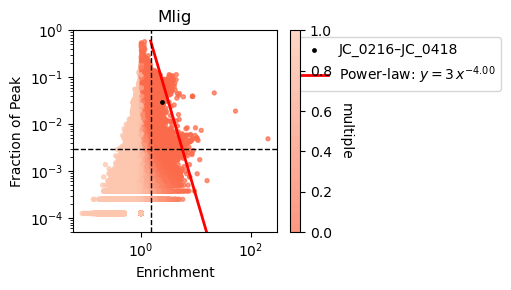

Highlighted rows: 1


In [470]:
# --- given fit parameters ---
alpha =4
c = 3

# --- choose x-range for the curve ---
x_min, x_max = 1.5, 40     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))

# --- highlight the specific pair (order-independent) ---
a, b = "JC_0216", "JC_0418"
mask_pair = (
    ((Mlig_filtered["motif_1"] == a) & (Mlig_filtered["variable"] == b)) |
    ((Mlig_filtered["motif_1"] == b) & (Mlig_filtered["variable"] == a))
)

plt.figure(figsize=(5,3))

# ---- base scatter (everything except highlighted) ----
sc = plt.scatter(
    Mlig_filtered.loc[~mask_pair, "Enrichment"],
    Mlig_filtered.loc[~mask_pair, "Peak"],
    c=Mlig_filtered.loc[~mask_pair, "multiple"],
    cmap=cmap,
    alpha=0.7,
    s=8,
    rasterized=True
)

# ---- highlighted motif pair ----
plt.scatter(
    Mlig_filtered.loc[mask_pair, "Enrichment"],
    Mlig_filtered.loc[mask_pair, "Peak"],
    color="black",
    s=6,
    zorder=10,
    label=f"{a}–{b}",
)

# ---- colorbar ----
cbar = plt.colorbar(sc)
cbar.set_label("multiple", rotation=270, labelpad=15)

# ---- overlay curve ----
plt.plot(
    x_line, y_line, lw=2, color="red",
    label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$"
)

plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005, 1])

plt.axhline(y=0.003, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("Mlig")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig("./Figures/Schisto_cooccurrence_rasterized.svg",dpi=600)
plt.show()

# optional sanity check
print("Highlighted rows:", mask_pair.sum())

In [471]:
Mlig_filtered_powerlaw = apply_powerlaw_threshold(
    Mlig_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=3,
    x_min=1.5, y_min=0.003,
    keep="above"
)

# points that pass
Mlig_filtered_passed = Mlig_filtered_powerlaw[Mlig_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(Mlig_filtered_passed)} points passed out of {len(Mlig_filtered_powerlaw)}")

154 points passed out of 55611


/tmp/ipykernel_15961/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### Smed

In [472]:
## Here plotting fraction of peaks to enrichment color coded by Fisher
Smed_rawpeaks = pd.read_csv("../../Cooccurence/Smed/Figure4_Jesseneuralmotifs_SHAPunfiltered/Smed_rawunfiltered_peakcounts_3_15_26.tsv",sep="\t",index_col=0)
Smed_enrichment = pd.read_csv("../../Cooccurence/Smed/Figure4_Jesseneuralmotifs_SHAPunfiltered/Smed_Jesseneural_enriched_8_07_25_union.tsv",sep="\t",index_col=0)
Smed_fisher = pd.read_csv("../../Cooccurence/Smed/Figure4_Jesseneuralmotifs_SHAPunfiltered/Smed_Jesseneural_enriched_fishertest_8_07_25_union.tsv",sep="\t",index_col=0)

In [473]:
# Raw peaks
Smed_rawpeaks_motif_list = list(Smed_rawpeaks.columns)
Smed_rawpeaks_long = pd.melt(Smed_rawpeaks, value_vars=Smed_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
Smed_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(Smed_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Smed_rawpeaks_long.index)
Smed_rawpeaks_long_final = Smed_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
Smed_rawpeaks_long_final = Smed_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
Smed_enrichment_motif_list = list(Smed_enrichment.columns)
Smed_enrichment_long = pd.melt(Smed_enrichment, value_vars=Smed_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
Smed_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(Smed_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Smed_enrichment_long.index)
Smed_enrichment_long_final = Smed_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
Smed_enrichment_long_final = Smed_enrichment_long_final.reset_index(drop=True)

# Fisher 
alpha = 0.1 
Smed_fisher_motif_list = list(Smed_fisher.columns)
Smed_fisher_long = pd.melt(Smed_fisher, value_vars=Smed_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
Smed_fisher_long[['motif_1', 'variable']] = pd.DataFrame(Smed_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Smed_fisher_long.index)
Smed_fisher_long_final = Smed_fisher_long.drop_duplicates(subset=['motif_1','variable'])
Smed_fisher_long_final.loc[Smed_fisher_long_final['motif_1'] == Smed_fisher_long_final['variable'], 'Fisher'] = 1
Smed_fisher_long_final = Smed_fisher_long_final.reset_index(drop=True)
Smed_fisher_counts = Smed_fisher_long_final.Fisher.to_numpy()
_, p, _, _ = sm.stats.multipletests( Smed_fisher_counts, alpha=alpha,method='fdr_bh' )
Smed_fisher_long_final['multiple'] = p

In [474]:
Smed_merged = Smed_rawpeaks_long_final.merge(Smed_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(Smed_fisher_long_final, on=["motif_1", "variable"], how="outer") \

Smed_neural_totalpeak = pd.read_csv('../../motif_filtration/neural_muscle/pl_Neural_final.csv',sep=',',index_col=0).shape[0]

Smed_merged['Peak'] = Smed_merged['Peak']/Smed_neural_totalpeak
Smed_filtered = Smed_merged[Smed_merged["motif_1"] != Smed_merged["variable"]]


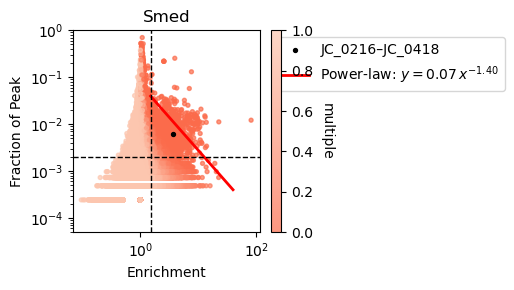

Highlighted rows: 1


In [475]:
# --- given fit parameters ---
alpha = 1.4
c = 0.07

# --- choose x-range for the curve ---
x_min, x_max = 1.5, 40     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))


# --- highlight the specific pair (order-independent) ---
a, b = "JC_0216", "JC_0418"
mask_pair = (
    ((Smed_filtered["motif_1"] == a) & (Smed_filtered["variable"] == b)) |
    ((Smed_filtered["motif_1"] == b) & (Smed_filtered["variable"] == a))
)

plt.figure(figsize=(5,3))

# ---- base scatter (everything except highlighted) ----
sc = plt.scatter(
    Smed_filtered.loc[~mask_pair, "Enrichment"],
    Smed_filtered.loc[~mask_pair, "Peak"],
    c=Smed_filtered.loc[~mask_pair, "multiple"],
    cmap=cmap,
    alpha=0.7,
    s=8,
    rasterized=True
)

# ---- highlighted motif pair ----
plt.scatter(
    Smed_filtered.loc[mask_pair, "Enrichment"],
    Smed_filtered.loc[mask_pair, "Peak"],
    color="black",
    s=8,
    zorder=10,
    label=f"{a}–{b}",
)

# ---- colorbar ----
cbar = plt.colorbar(sc)
cbar.set_label("multiple", rotation=270, labelpad=15)

# ---- overlay curve ----
plt.plot(
    x_line, y_line, lw=2, color="red",
    label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$"
)

plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005, 1])

plt.axhline(y=0.002, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("Smed")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig("./Figures/Schisto_cooccurrence_rasterized.svg",dpi=600)
plt.show()

# optional sanity check
print("Highlighted rows:", mask_pair.sum())

In [476]:
Smed_filtered_powerlaw = apply_powerlaw_threshold(
    Smed_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=1.4, c=0.07,
    x_min=1.5, y_min=0.002,
    keep="above"
)

# points that pass
Smed_filtered_passed = Smed_filtered_powerlaw[Smed_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(Smed_filtered_passed)} points passed out of {len(Smed_filtered_powerlaw)}")

196 points passed out of 55611


/tmp/ipykernel_15961/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### Schisto

In [477]:
## Here plotting fraction of peaks to enrichment color coded by Fisher
schisto_rawpeaks = pd.read_csv("../../Cooccurence/schisto/Figure4_Jesseneuralmotifs_SHAPunfiltered/schisto_rawunfiltered_peakcounts_3_15_26.tsv",sep="\t",index_col=0)
schisto_enrichment = pd.read_csv("../../Cooccurence/schisto/Figure4_Jesseneuralmotifs_SHAPunfiltered/schisto_Jesseneural_enriched_8_07_25_union.tsv",sep="\t",index_col=0)
schisto_fisher = pd.read_csv("../../Cooccurence/schisto/Figure4_Jesseneuralmotifs_SHAPunfiltered/schisto_Jesseneural_enriched_fishertest_8_07_25_union.tsv",sep="\t",index_col=0)

In [478]:
# Raw peaks
schisto_rawpeaks_motif_list = list(schisto_rawpeaks.columns)
schisto_rawpeaks_long = pd.melt(schisto_rawpeaks, value_vars=schisto_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
schisto_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(schisto_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=schisto_rawpeaks_long.index)
schisto_rawpeaks_long_final = schisto_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
schisto_rawpeaks_long_final = schisto_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
schisto_enrichment_motif_list = list(schisto_enrichment.columns)
schisto_enrichment_long = pd.melt(schisto_enrichment, value_vars=schisto_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
schisto_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(schisto_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=schisto_enrichment_long.index)
schisto_enrichment_long_final = schisto_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
schisto_enrichment_long_final = schisto_enrichment_long_final.reset_index(drop=True)

# Fisher 
alpha = 0.1 
schisto_fisher_motif_list = list(schisto_fisher.columns)
schisto_fisher_long = pd.melt(schisto_fisher, value_vars=schisto_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
schisto_fisher_long[['motif_1', 'variable']] = pd.DataFrame(schisto_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=schisto_fisher_long.index)
schisto_fisher_long_final = schisto_fisher_long.drop_duplicates(subset=['motif_1','variable'])
schisto_fisher_long_final.loc[schisto_fisher_long_final['motif_1'] == schisto_fisher_long_final['variable'], 'Fisher'] = 1
schisto_fisher_long_final = schisto_fisher_long_final.reset_index(drop=True)
schisto_fisher_counts = schisto_fisher_long_final.Fisher.to_numpy()
_, p, _, _ = sm.stats.multipletests( schisto_fisher_counts, alpha=alpha,method='fdr_bh' )
schisto_fisher_long_final['multiple'] = p


In [479]:
schisto_merged = schisto_rawpeaks_long_final.merge(schisto_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(schisto_fisher_long_final, on=["motif_1", "variable"], how="outer") \

neural_totalpeak = pd.read_csv('../../motif_filtration/neural_muscle/schisto_Neural_final.csv',sep=',',index_col=0).shape[0]

schisto_merged['Peak'] = schisto_merged['Peak']/neural_totalpeak
schisto_filtered = schisto_merged[schisto_merged["motif_1"] != schisto_merged["variable"]]


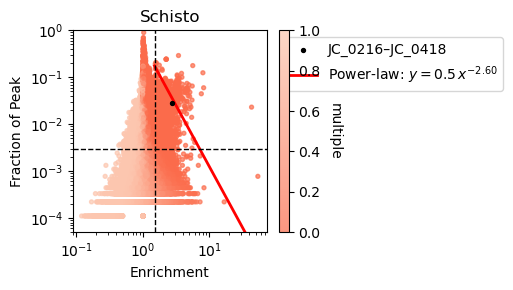

Highlighted rows: 1


In [480]:
# --- given fit parameters ---
alpha = 2.6
c = 0.5

# --- choose x-range for the curve ---
x_min, x_max = 1.5, 40     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))


# --- highlight the specific pair (order-independent) ---
a, b = "JC_0216", "JC_0418"
mask_pair = (
    ((schisto_filtered["motif_1"] == a) & (schisto_filtered["variable"] == b)) |
    ((schisto_filtered["motif_1"] == b) & (schisto_filtered["variable"] == a))
)

plt.figure(figsize=(5,3))

# ---- base scatter (everything except highlighted) ----
sc = plt.scatter(
    schisto_filtered.loc[~mask_pair, "Enrichment"],
    schisto_filtered.loc[~mask_pair, "Peak"],
    c=schisto_filtered.loc[~mask_pair, "multiple"],
    cmap=cmap,
    alpha=0.7,
    s=8,
    rasterized=True
)

# ---- highlighted motif pair ----
plt.scatter(
    schisto_filtered.loc[mask_pair, "Enrichment"],
    schisto_filtered.loc[mask_pair, "Peak"],
    color="black",
    s=8,
    zorder=10,
    label=f"{a}–{b}",
)

# ---- colorbar ----
cbar = plt.colorbar(sc)
cbar.set_label("multiple", rotation=270, labelpad=15)

# ---- overlay curve ----
plt.plot(
    x_line, y_line, lw=2, color="red",
    label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$"
)

plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005, 1])

plt.axhline(y=0.003, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("Schisto")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig("./Figures/Schisto_cooccurrence_rasterized.svg",dpi=600)
plt.show()

# optional sanity check
print("Highlighted rows:", mask_pair.sum())

In [481]:
schisto_filtered_powerlaw = apply_powerlaw_threshold(
    schisto_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=2.6, c=0.5,
    x_min=1.5, y_min=0.003,
    keep="above"
)

# points that pass
schisto_filtered_passed = schisto_filtered_powerlaw[schisto_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(schisto_filtered_passed)} points passed out of {len(schisto_filtered_powerlaw)}")


184 points passed out of 55611


/tmp/ipykernel_15961/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


In [482]:
schisto_filtered_passed = canonicalize_pairs(schisto_filtered_passed)
Mlig_filtered_passed = canonicalize_pairs(Mlig_filtered_passed)
Smed_filtered_passed = canonicalize_pairs(Smed_filtered_passed)

In [483]:
common_Mlig_Smed = Mlig_filtered_passed.merge(Smed_filtered_passed, on="pair_key", suffixes=("_Mlig", "_Smed"))
common_Mlig_schisto = Mlig_filtered_passed.merge(schisto_filtered_passed, on="pair_key", suffixes=("_Mlig", "_schisto"))
common_Smed_schisto = Smed_filtered_passed.merge(schisto_filtered_passed, on="pair_key", suffixes=("_Smed", "_schisto"))


In [484]:
len(common_Mlig_Smed)

55

In [485]:
len(common_Mlig_schisto)

76

In [486]:
len(common_Smed_schisto)

123

In [487]:
# 1. Get the set of pair_keys present in all three
common_keys_all3 = (
    set(Mlig_filtered_passed["pair_key"])
    & set(Smed_filtered_passed["pair_key"])
    & set(schisto_filtered_passed["pair_key"])
)

# Optional: check how many
print("Number of motif pairs shared by all three:", len(common_keys_all3))

Number of motif pairs shared by all three: 47


/tmp/ipykernel_15961/1829578266.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Value', data=df, ax=ax, palette='viridis')


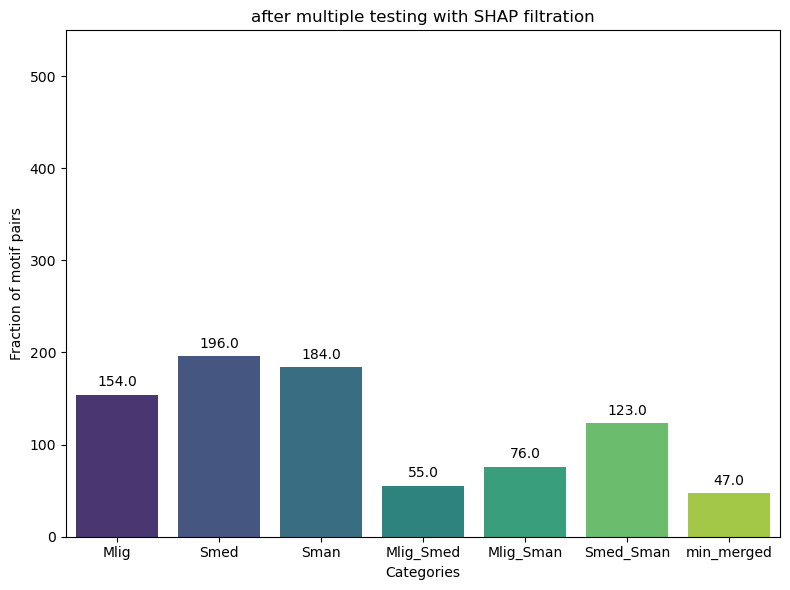

In [488]:

data = {
    'Category': ['Mlig', 'Smed', 'Sman', 'Mlig_Smed','Mlig_Sman', 'Smed_Sman', 'min_merged'],
    'Value': [len(Mlig_filtered_passed), len(Smed_filtered_passed), len(schisto_filtered_passed),
                  len(common_Mlig_Smed), len(common_Mlig_schisto), len(common_Smed_schisto), len(common_keys_all3)]
}
df = pd.DataFrame(data)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create bar plot using Seaborn
sns.barplot(x='Category', y='Value', data=df, ax=ax, palette='viridis')

# Add data labels
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

# Add titles and labels
ax.set_xlabel('Categories')
ax.set_ylabel('Fraction of motif pairs')
ax.set_title('after multiple testing with SHAP filtration')

# Show plot
plt.tight_layout()
plt.ylim([0,550])
plt.savefig("../../Cooccurence/Figures/allneuralmotifs_powerlaw_threshold_unfiltered_SHAP.svg")
plt.show()

### Gene motif

In [320]:
## Here plotting fraction of peaks to enrichment color coded by Fisher
Mlig_rawpeaks = pd.read_csv("../../Cooccurence/gene_motif/Mlig/Figure4_Jesseneuralmotifs/Mlig_rawfiltered_peakcounts_3_15_26.tsv",sep="\t",index_col=0)
Mlig_enrichment = pd.read_csv("../../Cooccurence/gene_motif/Mlig/Figure4_Jesseneuralmotifs/Mlig_Jesseneural_enriched_8_07_25_8k_union.tsv",sep="\t",index_col=0)
Mlig_fisher = pd.read_csv("../../Cooccurence/gene_motif/Mlig/Figure4_Jesseneuralmotifs/Mlig_Jesseneural_enriched_fishertest_8_07_25_8k_union.tsv",sep="\t",index_col=0)

In [321]:
# Raw peaks
Mlig_rawpeaks_motif_list = list(Mlig_rawpeaks.columns)
Mlig_rawpeaks_long = pd.melt(Mlig_rawpeaks, value_vars=Mlig_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
Mlig_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(Mlig_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Mlig_rawpeaks_long.index)
Mlig_rawpeaks_long_final = Mlig_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
Mlig_rawpeaks_long_final = Mlig_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
Mlig_enrichment_motif_list = list(Mlig_enrichment.columns)
Mlig_enrichment_long = pd.melt(Mlig_enrichment, value_vars=Mlig_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
Mlig_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(Mlig_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Mlig_enrichment_long.index)
Mlig_enrichment_long_final = Mlig_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
Mlig_enrichment_long_final = Mlig_enrichment_long_final.reset_index(drop=True)

# Fisher 
alpha = 0.1 
Mlig_fisher_motif_list = list(Mlig_fisher.columns)
Mlig_fisher_long = pd.melt(Mlig_fisher, value_vars=Mlig_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
Mlig_fisher_long[['motif_1', 'variable']] = pd.DataFrame(Mlig_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Mlig_fisher_long.index)
Mlig_fisher_long_final = Mlig_fisher_long.drop_duplicates(subset=['motif_1','variable'])
Mlig_fisher_long_final.loc[Mlig_fisher_long_final['motif_1'] == Mlig_fisher_long_final['variable'], 'Fisher'] = 1
Mlig_fisher_long_final = Mlig_fisher_long_final.reset_index(drop=True)
Mlig_fisher_counts = Mlig_fisher_long_final.Fisher.to_numpy()
_, p, _, _ = sm.stats.multipletests( Mlig_fisher_counts, alpha=alpha,method='fdr_bh' )
Mlig_fisher_long_final['multiple'] = p

In [322]:
Mlig_merged = Mlig_rawpeaks_long_final.merge(Mlig_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(Mlig_fisher_long_final, on=["motif_1", "variable"], how="outer") \

Mlig_merged['Peak'] = Mlig_merged['Peak']/8000
Mlig_filtered = Mlig_merged[Mlig_merged["motif_1"] != Mlig_merged["variable"]]

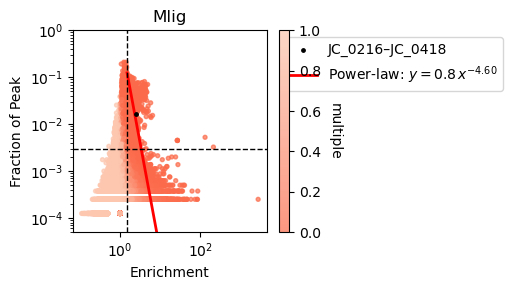

Highlighted rows: 1


In [414]:
# --- given fit parameters ---
alpha =4.6
c = 0.8

# --- choose x-range for the curve ---
x_min, x_max = 1.5, 40     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))

# --- highlight the specific pair (order-independent) ---
a, b = "JC_0216", "JC_0418"
mask_pair = (
    ((Mlig_filtered["motif_1"] == a) & (Mlig_filtered["variable"] == b)) |
    ((Mlig_filtered["motif_1"] == b) & (Mlig_filtered["variable"] == a))
)

plt.figure(figsize=(5,3))

# ---- base scatter (everything except highlighted) ----
sc = plt.scatter(
    Mlig_filtered.loc[~mask_pair, "Enrichment"],
    Mlig_filtered.loc[~mask_pair, "Peak"],
    c=Mlig_filtered.loc[~mask_pair, "multiple"],
    cmap=cmap,
    alpha=0.7,
    s=8,
    rasterized=True
)

# ---- highlighted motif pair ----
plt.scatter(
    Mlig_filtered.loc[mask_pair, "Enrichment"],
    Mlig_filtered.loc[mask_pair, "Peak"],
    color="black",
    s=6,
    zorder=10,
    label=f"{a}–{b}",
)

# ---- colorbar ----
cbar = plt.colorbar(sc)
cbar.set_label("multiple", rotation=270, labelpad=15)

# ---- overlay curve ----
plt.plot(
    x_line, y_line, lw=2, color="red",
    label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$"
)

plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005, 1])

plt.axhline(y=0.003, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("Mlig")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig("./Figures/Schisto_cooccurrence_rasterized.svg",dpi=600)
plt.show()

# optional sanity check
print("Highlighted rows:", mask_pair.sum())

In [415]:
Mlig_filtered_powerlaw = apply_powerlaw_threshold(
    Mlig_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4.6, c=0.8,
    x_min=1.5, y_min=0.003,
    keep="above"
)

# points that pass
Mlig_filtered_passed = Mlig_filtered_powerlaw[Mlig_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(Mlig_filtered_passed)} points passed out of {len(Mlig_filtered_powerlaw)}")

514 points passed out of 54615


/tmp/ipykernel_15961/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### Smed

In [416]:
## Here plotting fraction of peaks to enrichment color coded by Fisher
Smed_rawpeaks = pd.read_csv("../../Cooccurence/gene_motif/Smed/Figure4_Jesseneuralmotifs/Smed_rawfiltered_peakcounts_3_15_26.tsv",sep="\t",index_col=0)
Smed_enrichment = pd.read_csv("../../Cooccurence/gene_motif/Smed/Figure4_Jesseneuralmotifs/Smed_Jesseneural_enriched_8_07_25_union.tsv",sep="\t",index_col=0)
Smed_fisher = pd.read_csv("../../Cooccurence/gene_motif/Smed/Figure4_Jesseneuralmotifs/Smed_Jesseneural_enriched_fishertest_8_07_25_union.tsv",sep="\t",index_col=0)

In [417]:
# Raw peaks
Smed_rawpeaks_motif_list = list(Smed_rawpeaks.columns)
Smed_rawpeaks_long = pd.melt(Smed_rawpeaks, value_vars=Smed_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
Smed_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(Smed_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Smed_rawpeaks_long.index)
Smed_rawpeaks_long_final = Smed_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
Smed_rawpeaks_long_final = Smed_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
Smed_enrichment_motif_list = list(Smed_enrichment.columns)
Smed_enrichment_long = pd.melt(Smed_enrichment, value_vars=Smed_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
Smed_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(Smed_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Smed_enrichment_long.index)
Smed_enrichment_long_final = Smed_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
Smed_enrichment_long_final = Smed_enrichment_long_final.reset_index(drop=True)

# Fisher 
alpha = 0.1 
Smed_fisher_motif_list = list(Smed_fisher.columns)
Smed_fisher_long = pd.melt(Smed_fisher, value_vars=Smed_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
Smed_fisher_long[['motif_1', 'variable']] = pd.DataFrame(Smed_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Smed_fisher_long.index)
Smed_fisher_long_final = Smed_fisher_long.drop_duplicates(subset=['motif_1','variable'])
Smed_fisher_long_final.loc[Smed_fisher_long_final['motif_1'] == Smed_fisher_long_final['variable'], 'Fisher'] = 1
Smed_fisher_long_final = Smed_fisher_long_final.reset_index(drop=True)
Smed_fisher_counts = Smed_fisher_long_final.Fisher.to_numpy()
_, p, _, _ = sm.stats.multipletests( Smed_fisher_counts, alpha=alpha,method='fdr_bh' )
Smed_fisher_long_final['multiple'] = p

In [418]:
Smed_merged = Smed_rawpeaks_long_final.merge(Smed_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(Smed_fisher_long_final, on=["motif_1", "variable"], how="outer") \

Smed_neural_totalpeak = pd.read_csv('../../motif_filtration/neural_muscle/pl_Neural_final.csv',sep=',',index_col=0).shape[0]

Smed_merged['Peak'] = Smed_merged['Peak']/Smed_neural_totalpeak
Smed_filtered = Smed_merged[Smed_merged["motif_1"] != Smed_merged["variable"]]


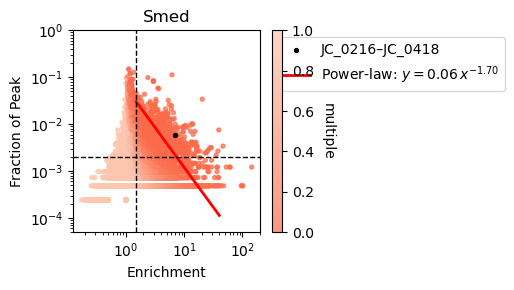

Highlighted rows: 1


In [441]:
# --- given fit parameters ---
alpha = 1.7
c = 0.06

# --- choose x-range for the curve ---
x_min, x_max = 1.5, 40     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))


# --- highlight the specific pair (order-independent) ---
a, b = "JC_0216", "JC_0418"
mask_pair = (
    ((Smed_filtered["motif_1"] == a) & (Smed_filtered["variable"] == b)) |
    ((Smed_filtered["motif_1"] == b) & (Smed_filtered["variable"] == a))
)

plt.figure(figsize=(5,3))

# ---- base scatter (everything except highlighted) ----
sc = plt.scatter(
    Smed_filtered.loc[~mask_pair, "Enrichment"],
    Smed_filtered.loc[~mask_pair, "Peak"],
    c=Smed_filtered.loc[~mask_pair, "multiple"],
    cmap=cmap,
    alpha=0.7,
    s=8,
    rasterized=True
)

# ---- highlighted motif pair ----
plt.scatter(
    Smed_filtered.loc[mask_pair, "Enrichment"],
    Smed_filtered.loc[mask_pair, "Peak"],
    color="black",
    s=8,
    zorder=10,
    label=f"{a}–{b}",
)

# ---- colorbar ----
cbar = plt.colorbar(sc)
cbar.set_label("multiple", rotation=270, labelpad=15)

# ---- overlay curve ----
plt.plot(
    x_line, y_line, lw=2, color="red",
    label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$"
)

plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005, 1])

plt.axhline(y=0.002, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("Smed")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig("./Figures/Schisto_cooccurrence_rasterized.svg",dpi=600)
plt.show()

# optional sanity check
print("Highlighted rows:", mask_pair.sum())

In [459]:
Smed_filtered_powerlaw = apply_powerlaw_threshold(
    Smed_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=1.63, c=0.06,
    x_min=1.5, y_min=0.002,
    keep="above"
)

# points that pass
Smed_filtered_passed = Smed_filtered_powerlaw[Smed_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(Smed_filtered_passed)} points passed out of {len(Smed_filtered_powerlaw)}")

345 points passed out of 54285


/tmp/ipykernel_15961/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### Schisto

In [423]:
## Here plotting fraction of peaks to enrichment color coded by Fisher
schisto_rawpeaks = pd.read_csv("../../Cooccurence/gene_motif/schisto/Figure4_Jesseneuralmotifs/schisto_rawfiltered_peakcounts_3_15_26.tsv",sep="\t",index_col=0)
schisto_enrichment = pd.read_csv("../../Cooccurence/gene_motif/schisto/Figure4_Jesseneuralmotifs/schisto_Jesseneural_enriched_8_07_25_union.tsv",sep="\t",index_col=0)
schisto_fisher = pd.read_csv("../../Cooccurence/gene_motif/schisto/Figure4_Jesseneuralmotifs/schisto_Jesseneural_enriched_fishertest_8_07_25_union.tsv",sep="\t",index_col=0)

In [424]:
# Raw peaks
schisto_rawpeaks_motif_list = list(schisto_rawpeaks.columns)
schisto_rawpeaks_long = pd.melt(schisto_rawpeaks, value_vars=schisto_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
schisto_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(schisto_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=schisto_rawpeaks_long.index)
schisto_rawpeaks_long_final = schisto_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
schisto_rawpeaks_long_final = schisto_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
schisto_enrichment_motif_list = list(schisto_enrichment.columns)
schisto_enrichment_long = pd.melt(schisto_enrichment, value_vars=schisto_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
schisto_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(schisto_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=schisto_enrichment_long.index)
schisto_enrichment_long_final = schisto_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
schisto_enrichment_long_final = schisto_enrichment_long_final.reset_index(drop=True)

# Fisher 
alpha = 0.1 
schisto_fisher_motif_list = list(schisto_fisher.columns)
schisto_fisher_long = pd.melt(schisto_fisher, value_vars=schisto_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
schisto_fisher_long[['motif_1', 'variable']] = pd.DataFrame(schisto_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=schisto_fisher_long.index)
schisto_fisher_long_final = schisto_fisher_long.drop_duplicates(subset=['motif_1','variable'])
schisto_fisher_long_final.loc[schisto_fisher_long_final['motif_1'] == schisto_fisher_long_final['variable'], 'Fisher'] = 1
schisto_fisher_long_final = schisto_fisher_long_final.reset_index(drop=True)
schisto_fisher_counts = schisto_fisher_long_final.Fisher.to_numpy()
_, p, _, _ = sm.stats.multipletests( schisto_fisher_counts, alpha=alpha,method='fdr_bh' )
schisto_fisher_long_final['multiple'] = p


In [425]:
schisto_merged = schisto_rawpeaks_long_final.merge(schisto_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(schisto_fisher_long_final, on=["motif_1", "variable"], how="outer") \

neural_totalpeak = pd.read_csv('../../motif_filtration/neural_muscle/schisto_Neural_final.csv',sep=',',index_col=0).shape[0]

schisto_merged['Peak'] = schisto_merged['Peak']/neural_totalpeak
schisto_filtered = schisto_merged[schisto_merged["motif_1"] != schisto_merged["variable"]]


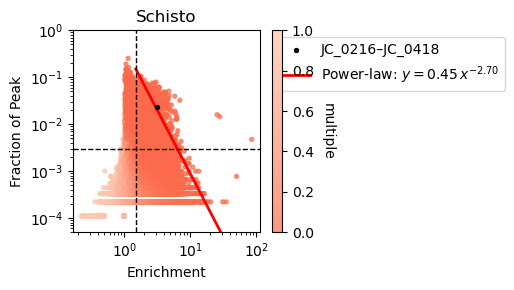

Highlighted rows: 1


In [426]:
# --- given fit parameters ---
alpha = 2.7
c = 0.45

# --- choose x-range for the curve ---
x_min, x_max = 1.5, 40     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))


# --- highlight the specific pair (order-independent) ---
a, b = "JC_0216", "JC_0418"
mask_pair = (
    ((schisto_filtered["motif_1"] == a) & (schisto_filtered["variable"] == b)) |
    ((schisto_filtered["motif_1"] == b) & (schisto_filtered["variable"] == a))
)

plt.figure(figsize=(5,3))

# ---- base scatter (everything except highlighted) ----
sc = plt.scatter(
    schisto_filtered.loc[~mask_pair, "Enrichment"],
    schisto_filtered.loc[~mask_pair, "Peak"],
    c=schisto_filtered.loc[~mask_pair, "multiple"],
    cmap=cmap,
    alpha=0.7,
    s=8,
    rasterized=True
)

# ---- highlighted motif pair ----
plt.scatter(
    schisto_filtered.loc[mask_pair, "Enrichment"],
    schisto_filtered.loc[mask_pair, "Peak"],
    color="black",
    s=8,
    zorder=10,
    label=f"{a}–{b}",
)

# ---- colorbar ----
cbar = plt.colorbar(sc)
cbar.set_label("multiple", rotation=270, labelpad=15)

# ---- overlay curve ----
plt.plot(
    x_line, y_line, lw=2, color="red",
    label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$"
)

plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005, 1])

plt.axhline(y=0.003, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("Schisto")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig("./Figures/Schisto_cooccurrence_rasterized.svg",dpi=600)
plt.show()

# optional sanity check
print("Highlighted rows:", mask_pair.sum())

In [427]:
schisto_filtered_powerlaw = apply_powerlaw_threshold(
    schisto_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=2.7, c=0.42,
    x_min=1.5, y_min=0.003,
    keep="above"
)

# points that pass
schisto_filtered_passed = schisto_filtered_powerlaw[schisto_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(schisto_filtered_passed)} points passed out of {len(schisto_filtered_powerlaw)}")


398 points passed out of 55611


/tmp/ipykernel_15961/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


In [460]:
schisto_filtered_passed = canonicalize_pairs(schisto_filtered_passed)
Mlig_filtered_passed = canonicalize_pairs(Mlig_filtered_passed)
Smed_filtered_passed = canonicalize_pairs(Smed_filtered_passed)

In [461]:
common_Mlig_Smed = Mlig_filtered_passed.merge(Smed_filtered_passed, on="pair_key", suffixes=("_Mlig", "_Smed"))
common_Mlig_schisto = Mlig_filtered_passed.merge(schisto_filtered_passed, on="pair_key", suffixes=("_Mlig", "_schisto"))
common_Smed_schisto = Smed_filtered_passed.merge(schisto_filtered_passed, on="pair_key", suffixes=("_Smed", "_schisto"))


In [462]:
len(common_Mlig_Smed)

52

In [463]:
len(common_Mlig_schisto)

145

In [464]:
len(common_Smed_schisto)

173

In [465]:
# 1. Get the set of pair_keys present in all three
common_keys_all3 = (
    set(Mlig_filtered_passed["pair_key"])
    & set(Smed_filtered_passed["pair_key"])
    & set(schisto_filtered_passed["pair_key"])
)

# Optional: check how many
print("Number of motif pairs shared by all three:", len(common_keys_all3))

Number of motif pairs shared by all three: 50


/tmp/ipykernel_15961/3227164330.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Value', data=df, ax=ax, palette='viridis')


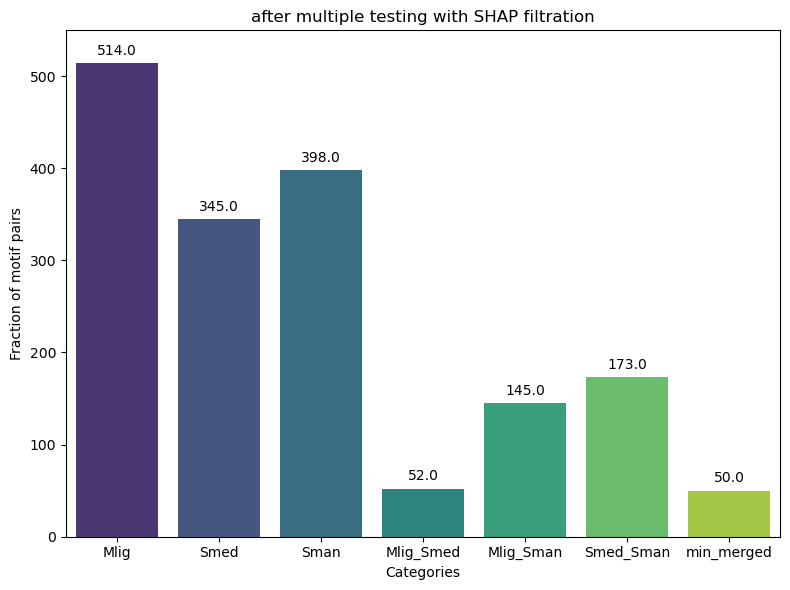

In [466]:

data = {
    'Category': ['Mlig', 'Smed', 'Sman', 'Mlig_Smed','Mlig_Sman', 'Smed_Sman', 'min_merged'],
    'Value': [len(Mlig_filtered_passed), len(Smed_filtered_passed), len(schisto_filtered_passed),
                  len(common_Mlig_Smed), len(common_Mlig_schisto), len(common_Smed_schisto), len(common_keys_all3)]
}
df = pd.DataFrame(data)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create bar plot using Seaborn
sns.barplot(x='Category', y='Value', data=df, ax=ax, palette='viridis')

# Add data labels
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

# Add titles and labels
ax.set_xlabel('Categories')
ax.set_ylabel('Fraction of motif pairs')
ax.set_title('after multiple testing with SHAP filtration')

# Show plot
plt.tight_layout()
plt.ylim([0,550])
plt.savefig("../../Cooccurence/Figures/allneuralmotifs_powerlaw_threshold_gene_motif.svg")
plt.show()